In [8]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="latin1")

# Show the first 5 rows
print(df.head())

# Show all columns
print(df.columns)

# Check the shape of the dataset
print(df.shape)

# Basic info
print(df.info())

# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print(df.duplicated().sum())



       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1                   1           73  Sporting Goo

NameError: name 'df_clean' is not defined

In [13]:
columns_to_keep = [
    'Type',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Delivery Status',
    'Late_delivery_risk',
    'Category Name',
    'Customer Segment',
    'Customer State',
    'Market',
    'Order City',
    'Order Country',
    'order date (DateOrders)',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Order Region',
    'Order State',
    'Order Status',
    'Product Name',
    'Product Price',
    'shipping date (DateOrders)',
    'Shipping Mode'
]

df_clean = df[columns_to_keep].copy()

# Delivery delay in days
df_clean['Delivery Delay'] = (
    df_clean['Days for shipping (real)'] -
    df_clean['Days for shipment (scheduled)']
)

# On-time flag
df_clean['On Time Delivery'] = df_clean['Delivery Delay'].apply(
    lambda x: 'On Time' if x <= 0 else 'Late'
)

# Profit Margin %
df_clean['Profit Margin %'] = (
    df_clean['Order Profit Per Order'] / df_clean['Sales']
) * 100

# Convert order/shipping dates to datetime
df_clean['order date (DateOrders)'] = pd.to_datetime(
    df_clean['order date (DateOrders)']
)

df_clean['shipping date (DateOrders)'] = pd.to_datetime(
    df_clean['shipping date (DateOrders)']
)

print(df_clean.head())
print(df_clean.shape)
print(df_clean.isnull().sum())


       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk   Category Name Customer Segment Customer State  ...  \
0                   0  Sporting Goods         Consumer             PR  ...   
1                   1  Sporting Goods 

In [17]:
# Create date features from order date
df_clean['Order Year'] = df_clean['order date (DateOrders)'].dt.year
df_clean['Order Month'] = df_clean['order date (DateOrders)'].dt.month
df_clean['Order Month Name'] = df_clean['order date (DateOrders)'].dt.month_name()
df_clean['Order Day'] = df_clean['order date (DateOrders)'].dt.day
df_clean['Order Weekday'] = df_clean['order date (DateOrders)'].dt.day_name()

# Optional: shipping date features too
df_clean['Shipping Year'] = df_clean['shipping date (DateOrders)'].dt.year
df_clean['Shipping Month'] = df_clean['shipping date (DateOrders)'].dt.month
df_clean['Shipping Month Name'] = df_clean['shipping date (DateOrders)'].dt.month_name()
df_clean['Shipping Day'] = df_clean['shipping date (DateOrders)'].dt.day
df_clean['Shipping Weekday'] = df_clean['shipping date (DateOrders)'].dt.day_name()

print(df_clean.head())
print(df_clean.shape)

df_clean.to_csv("DataCoSupplyChain_Cleaned.csv", index=False)

       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk   Category Name Customer Segment Customer State  ...  \
0                   0  Sporting Goods         Consumer             PR  ...   
1                   1  Sporting Goods 

In [26]:
# Overall on-time delivery %
print(df_clean['On Time Delivery'].value_counts(normalize=True) * 100)

# Average delivery delay
print(df_clean['Delivery Delay'].mean())

# Shipping mode performance
print(
    df_clean.groupby('Shipping Mode')['Delivery Delay']
    .mean()
    .sort_values()
)

# Shipping mode on-time %
print(
    df_clean.groupby('Shipping Mode')['On Time Delivery']
    .value_counts(normalize=True)
    .mul(100)
)

# Region delays
print(
    df_clean.groupby('Order Region')['Delivery Delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# State delays
print(
    df_clean.groupby('Order State')['Delivery Delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Profit by shipping mode
print(
    df_clean.groupby('Shipping Mode')['Order Profit Per Order']
    .mean()
    .sort_values(ascending=False)
)

# Sales by region
print(
    df_clean.groupby('Order Region')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

On Time Delivery
Late       57.279289
On Time    42.720711
Name: proportion, dtype: float64
0.5658074773292562
Shipping Mode
Standard Class   -0.004093
Same Day          0.478279
First Class       1.000000
Second Class      1.990828
Name: Delivery Delay, dtype: float64
Shipping Mode   On Time Delivery
First Class     Late                100.000000
Same Day        On Time              52.172127
                Late                 47.827873
Second Class    Late                 79.730804
                On Time              20.269196
Standard Class  On Time              60.231829
                Late                 39.768171
Name: proportion, dtype: float64
Order Region
Central Asia      0.645570
Central Africa    0.639833
South Asia        0.597465
Western Europe    0.597403
US Center         0.587226
East of USA       0.584816
South of  USA     0.579975
Eastern Europe    0.579847
East Africa       0.570734
West Asia         0.569479
Name: Delivery Delay, dtype: float64
Order State
Ila

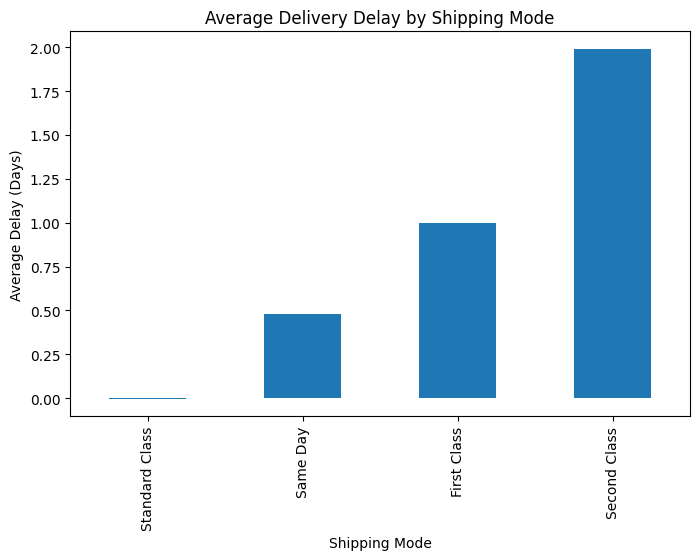

In [28]:
import matplotlib.pyplot as plt

shipping_delay = (
    df_clean.groupby('Shipping Mode')['Delivery Delay']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))
shipping_delay.plot(kind='bar')
plt.title('Average Delivery Delay by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Delay (Days)')
plt.show()

In [32]:
# On-time delivery percentage by shipping mode
on_time_shipping = (
    df_clean.groupby('Shipping Mode')['On Time Delivery']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
)

print(on_time_shipping)

# Top 10 regions with the worst delays
worst_regions = (
    df_clean.groupby('Order Region')['Delivery Delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(worst_regions)

# Top 10 states with the worst delays
worst_states = (
    df_clean.groupby('Order State')['Delivery Delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(worst_states)

Shipping Mode   On Time Delivery
First Class     Late                100.000000
Same Day        On Time              52.172127
                Late                 47.827873
Second Class    Late                 79.730804
                On Time              20.269196
Standard Class  On Time              60.231829
                Late                 39.768171
Name: Percentage, dtype: float64
Order Region
Central Asia      0.645570
Central Africa    0.639833
South Asia        0.597465
Western Europe    0.597403
US Center         0.587226
East of USA       0.584816
South of  USA     0.579975
Eastern Europe    0.579847
East Africa       0.570734
West Asia         0.569479
Name: Delivery Delay, dtype: float64
Order State
Ilam          3.200000
Vest-Agder    3.090909
Tlemcen       3.000000
Ar Raqa       3.000000
Suceava       3.000000
Isparta       3.000000
Olomouc       3.000000
Bitola        3.000000
Luxemburgo    2.700000
Golestán      2.666667
Name: Delivery Delay, dtype: float64


In [34]:
# Average profit per order by shipping mode
profit_shipping = (
    df_clean.groupby('Shipping Mode')['Order Profit Per Order']
    .mean()
    .sort_values(ascending=False)
)

print(profit_shipping)

# Sales by region
sales_region = (
    df_clean.groupby('Order Region')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(sales_region)

# Profit by region
profit_region = (
    df_clean.groupby('Order Region')['Order Profit Per Order']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(profit_region)

# Most used shipping modes
shipping_counts = df_clean['Shipping Mode'].value_counts()

print(shipping_counts)

Shipping Mode
First Class       23.122238
Standard Class    21.999169
Second Class      21.305889
Same Day          20.850203
Name: Order Profit Per Order, dtype: float64
Order Region
Western Europe     5.894381e+06
Central America    5.665712e+06
South America      2.960881e+06
Northern Europe    2.155831e+06
Southern Europe    2.047919e+06
Oceania            2.016654e+06
Southeast Asia     1.932496e+06
Caribbean          1.651019e+06
West of USA        1.571416e+06
South Asia         1.553681e+06
Name: Sales, dtype: float64
Order Region
Southern Africa    26.643086
Canada             24.922534
Southern Europe    24.475584
Northern Europe    23.840952
Central Asia       23.590018
East Africa        23.308709
Western Europe     23.071529
East of USA        22.597730
South America      22.440870
US Center          22.268427
Name: Order Profit Per Order, dtype: float64
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: 

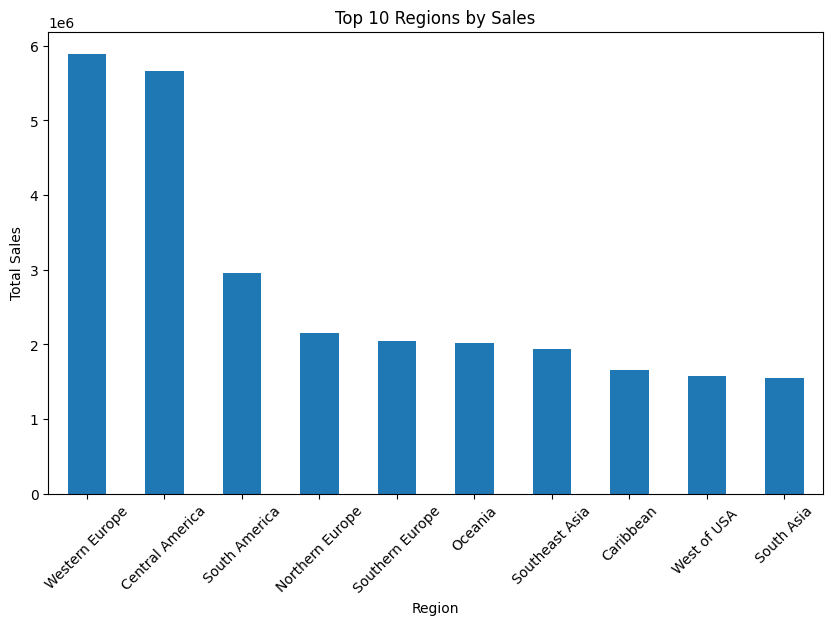

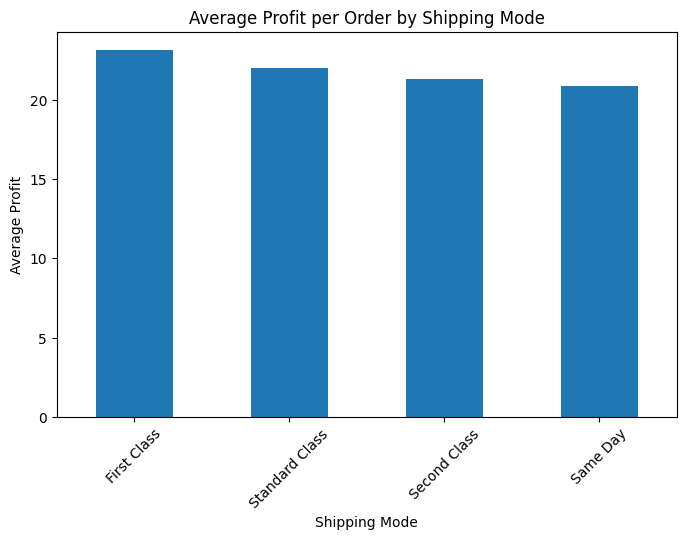

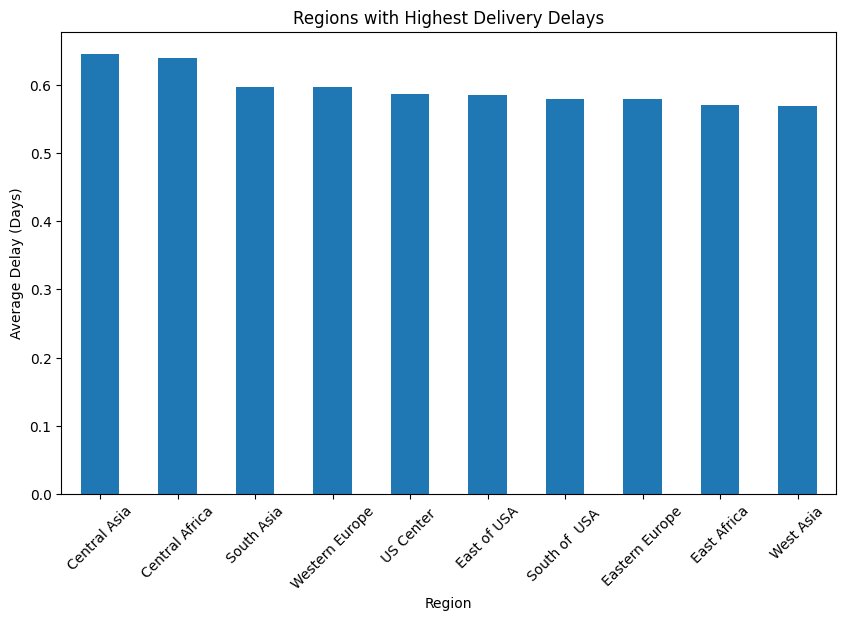

In [36]:
# Sales by region chart
sales_region.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Regions by Sales')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

# Profit by shipping mode chart
profit_shipping.plot(kind='bar', figsize=(8,5))
plt.title('Average Profit per Order by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.show()

# Worst delay regions chart
worst_regions.plot(kind='bar', figsize=(10,6))
plt.title('Regions with Highest Delivery Delays')
plt.xlabel('Region')
plt.ylabel('Average Delay (Days)')
plt.xticks(rotation=45)
plt.show()

In [38]:
from google.colab import files
files.download("DataCoSupplyChain_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>